In [1]:
from pathlib import Path
import runpy

BOOTSTRAP_CANDIDATES = (
    "notebooks/_bootstrap.py",
    "abstractgraph/notebooks/_bootstrap.py",
    "abstractgraph-ml/notebooks/_bootstrap.py",
    "abstractgraph-generative/notebooks/_bootstrap.py",
    "abstractgraph-graphicalizer/notebooks/_bootstrap.py",
)

_bootstrap_path = next(
    (
        candidate / relative
        for candidate in (Path.cwd(), *Path.cwd().parents)
        for relative in BOOTSTRAP_CANDIDATES
        if (candidate / relative).exists()
    ),
    None,
)
if _bootstrap_path is None:
    raise FileNotFoundError("Could not locate ecosystem notebooks/_bootstrap.py")

_bootstrap = runpy.run_path(str(_bootstrap_path))
repo_root = _bootstrap["repo_root"]
workspace_root = _bootstrap["workspace_root"]


In [2]:
%config InlineBackend.figure_format = 'retina'

import random
import numpy as np
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from nsppk import NSPPK

from abstractgraph.operators import *
from abstractgraph_graphicalizer.chem import ZINCLoader, draw_molecules as display_graphs
from abstractgraph_ml.estimators import GraphEstimator
from abstractgraph_ml.feasibility import (
    FeasibilityEstimator,
    FeasibilityEstimatorFeatureCannotExist,
)
from abstractgraph_generative.edge_generator import EdgeGenerator, edge_neighbors


In [3]:
loader = ZINCLoader(on_error="skip")

dataset_name = "zinc_250k"
size = 1000
min_num_nodes = 14
max_num_nodes = 16
USE_TARGETS = False

graphs, metadata = loader.load(
    dataset_name,
    limit=size,
    min_node_count=min_num_nodes,
    max_node_count=max_num_nodes,
)
targets = [max(dict(graph.degree()).values(), default=0) for graph in graphs] if USE_TARGETS else None

print(f"dataset: {dataset_name}")
print(f"n_graphs: {len(graphs)}")
print(f"node_range: [{min_num_nodes}, {max_num_nodes}]")
if USE_TARGETS:
    print("target: max_degree")
else:
    print("targets disabled")


dataset: zinc_250k
n_graphs: 1000
node_range: [14, 16]
targets disabled


In [4]:
vectorizer = NSPPK(radius=1, distance=4, connector=1, nbits=14, parallel=True)

feasibility_kwargs = dict(
    nbits=19,
    parallel=True,
    backend="loky",
    n_jobs=-1,
)
partial_feasibility_estimators = [
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=compose(neighborhood(radius=2), unlabel()),
        **feasibility_kwargs,
    ),
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=neighborhood(radius=1),
        **feasibility_kwargs,
    ),
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=cycle(), 
        **feasibility_kwargs,
    ),
]
partial_feasibility_estimator = FeasibilityEstimator(partial_feasibility_estimators)

final_feasibility_estimators = [
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=compose(neighborhood(radius=2), unlabel()),
        **feasibility_kwargs,
    ),
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=neighborhood(radius=1),
        **feasibility_kwargs,
    ),
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=compose(connected_component(), unlabel(), merge(use_edges=True), filter_by_edge_label(must_have_one_of=['aromatic']), edge()), 
        **feasibility_kwargs,
    ),
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=cycle(), 
        **feasibility_kwargs,
    ),
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=compose(combination(number_of_elements=2, distance=0), cycle(), unlabel()),
        **feasibility_kwargs,
    ),
]
final_feasibility_estimator = FeasibilityEstimator(final_feasibility_estimators)

graph_estimator = GraphEstimator(
    transformer=vectorizer,
    estimator=RandomForestClassifier(
        random_state=0,
        n_estimators=300,
        n_jobs=-1,
        class_weight="balanced_subsample",
    ),
)

target_estimator = None
if USE_TARGETS:
    target_estimator = GraphEstimator(
        transformer=NSPPK(radius=1, distance=4, connector=1, nbits=14, parallel=True),
        estimator=RandomForestRegressor(
            random_state=0,
            n_estimators=300,
            n_jobs=-1,
        ),
    )

generator = EdgeGenerator(
    partial_feasibility_estimator=partial_feasibility_estimator,
    final_feasibility_estimator=final_feasibility_estimator,
    graph_estimator=graph_estimator,
    target_estimator=target_estimator,
    target_estimator_mode="regression",
    decomposition_function=add(cycle(), tree()),
    enforce_diversity=False,
    n_negative_per_positive=5,
    n_replicates=5,
    beam_size=2,
    max_restarts=4,
    fit_n_jobs=-1,
    fit_backend="loky",
    verbose=True,
    seed=0,
)


In [5]:
%%time
generator.store(graphs, targets=targets)
print(f"stored_graphs = {len(generator.stored_graphs_)}")


stored_graphs = 1000
CPU times: user 29.7 s, sys: 620 ms, total: 30.3 s
Wall time: 32 s


## Repair Workflow

Select one stored molecule at random, perturb it by moving `k` edges at random,
then repair it with `EdgeGenerator.repair(...)` using the nearest stored
neighbors as the local fitting set.

graph_idx = 264
repair_target = None
k_edge_moves = 4
original_edges = 15
perturbed_edges = 15


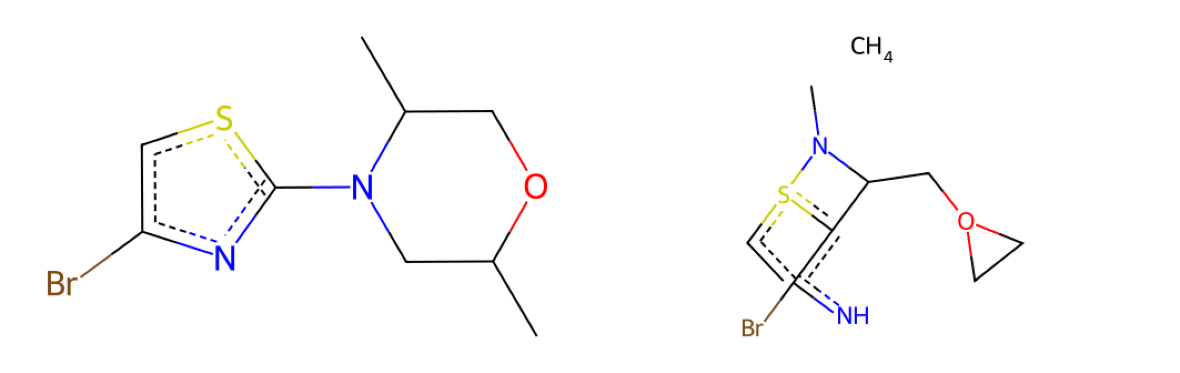

In [8]:
idx = random.randrange(len(graphs))
graph = graphs[idx]
repair_target = targets[idx] if USE_TARGETS else None

k = 4
perturb_seed = 0


def move_random_edges(graph, k, *, seed=0):
    perturbed = graph.copy()
    rng = random.Random(seed)
    for _ in range(max(0, int(k))):
        neighbors = edge_neighbors(
            perturbed,
            n_samples=1,
            seed=rng.randrange(10**9),
        )
        if not neighbors:
            break
        perturbed = neighbors[0]
    return perturbed


perturbed_graph = move_random_edges(graph, k, seed=perturb_seed)

print(f"graph_idx = {idx}")
print(f"repair_target = {repair_target}")
print(f"k_edge_moves = {k}")
print(f"original_edges = {graph.number_of_edges()}")
print(f"perturbed_edges = {perturbed_graph.number_of_edges()}")
_ = display_graphs([graph, perturbed_graph], n_graphs_per_line=2)

[repair] query_index=None n_neighbors=7 neighbor_indices=[235, 813, 631, 190, 240, 374, 532] neighbor_distances=[56.116, 56.1516, 56.2939, 57.0701, 57.9051, 59.8247, 60.05]


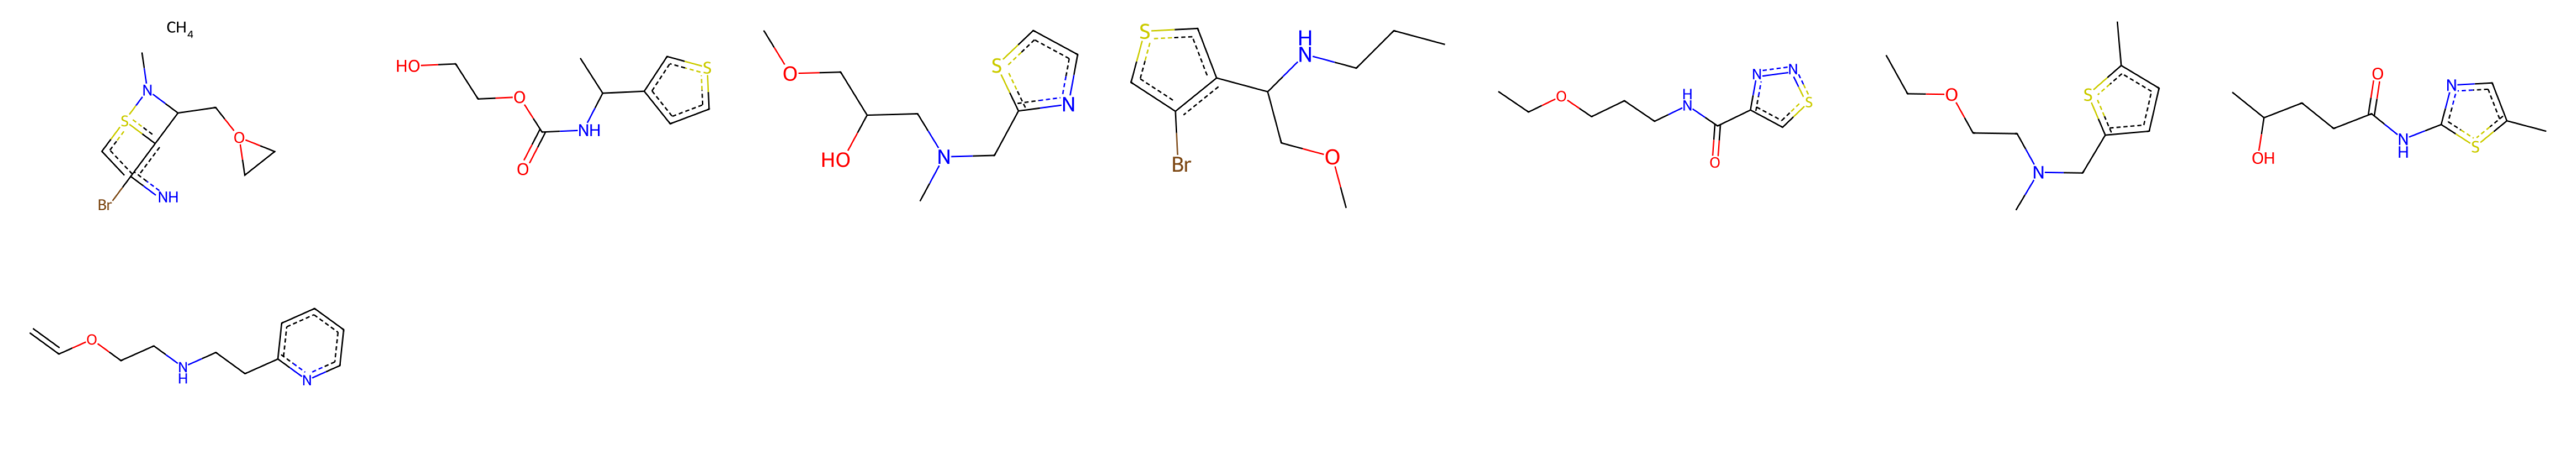

[fit] partial_feasibility_graphs=390 final_feasibility_graphs=7 positives=490 negatives=2275 dataset=2765 partial_time=0m 2.7s final_time=0m 0.6s
[fit] graph_estimator_graphs=2765 positive_labels=490 negative_labels=2275 time=1m 59.9s
[repair] attempt=1/4 start_edges=13 target_edges=15 removed_edges=[(9, 11), (6, 11)]


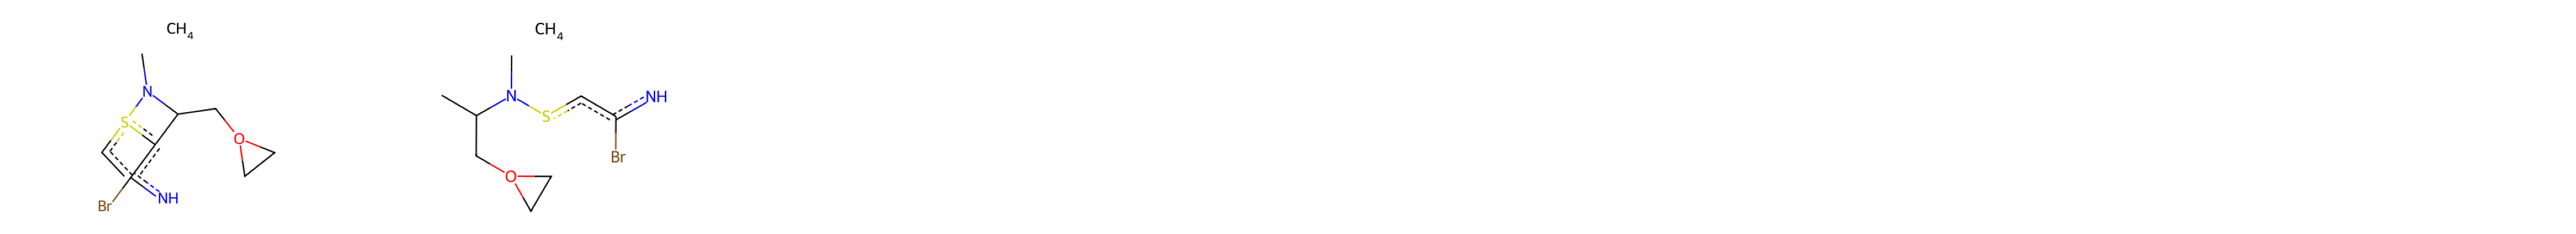

[graph 0] start start_edges=13 target_edges=15 remaining_edges=2


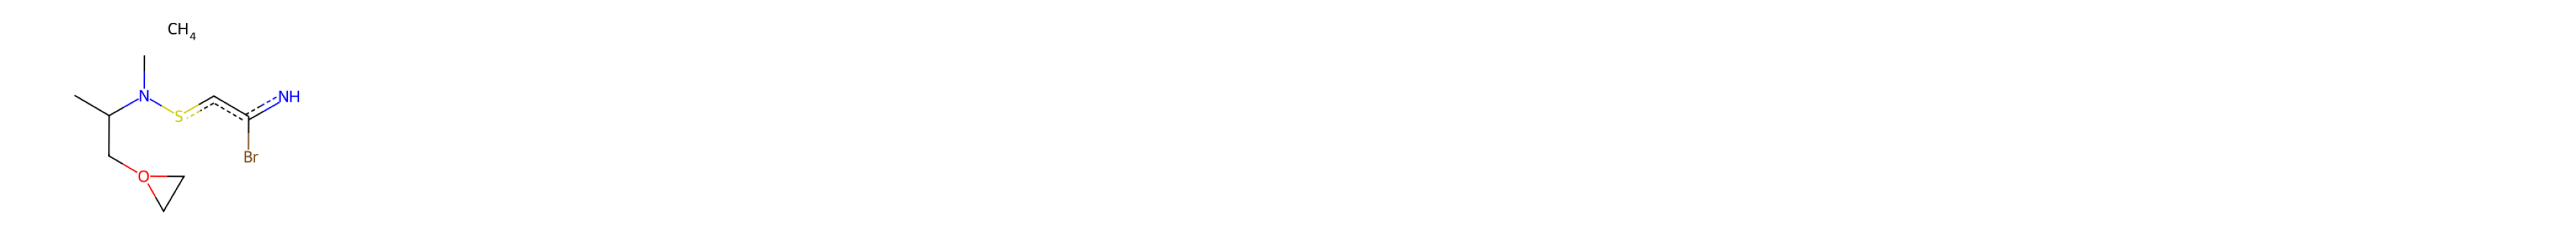

[graph 0] phase=1/5 beam_limit=2 fallback=0/4
[graph 0] phase=1/5 depth=1 remaining_edges=1 step_time=0m 5.2s eta=0m 5.2s
generated=234 feasible=0 retained=0 tried=234
best_score=None
beam_limit=2
[graph 0] fallback=1/4 rollback_steps=2 surgical_repairs=1 to_depth=0 beam_limit=3
[graph 0] surgical_removed_edges=['(1, 13),(0, 13)']
[graph 0] phase=2/5 beam_limit=3 fallback=1/4
[graph 0] phase=2/5 depth=1 remaining_edges=1 step_time=0m 5.6s eta=0m 5.6s
generated=240 feasible=0 retained=0 tried=474
best_score=None
beam_limit=3
[graph 0] fallback=2/4 rollback_steps=4 surgical_repairs=1 to_depth=0 beam_limit=5
[graph 0] surgical_removed_edges=['(3, 9),(3, 10),(6, 7),(6, 8)']
[graph 0] phase=3/5 beam_limit=5 fallback=2/4
[graph 0] phase=3/5 depth=1 remaining_edges=7 step_time=0m 6.4s eta=0m 44.7s
generated=252 feasible=64 retained=5 tried=726
best_score=0.336 best_selection_score=0.149 best_repulsion=0.624
repulsion_lambda=0.300 beam_limit=5


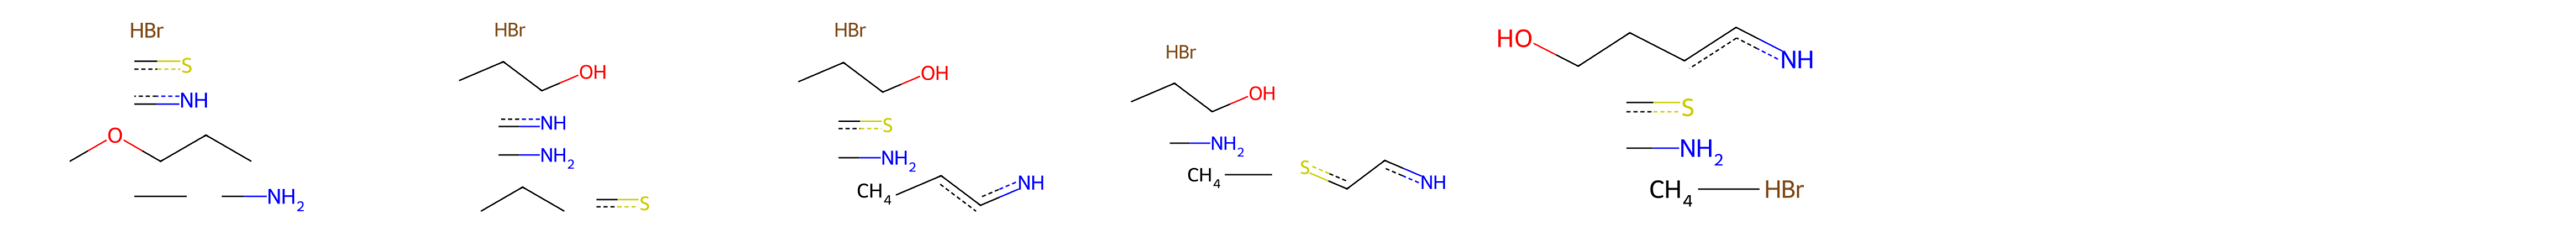

[graph 0] phase=3/5 depth=2 remaining_edges=6 step_time=0m 17.3s eta=1m 43.7s
generated=1245 feasible=239 retained=5 tried=1971
best_score=0.385 best_selection_score=0.193 best_repulsion=0.641
repulsion_lambda=0.300 beam_limit=5


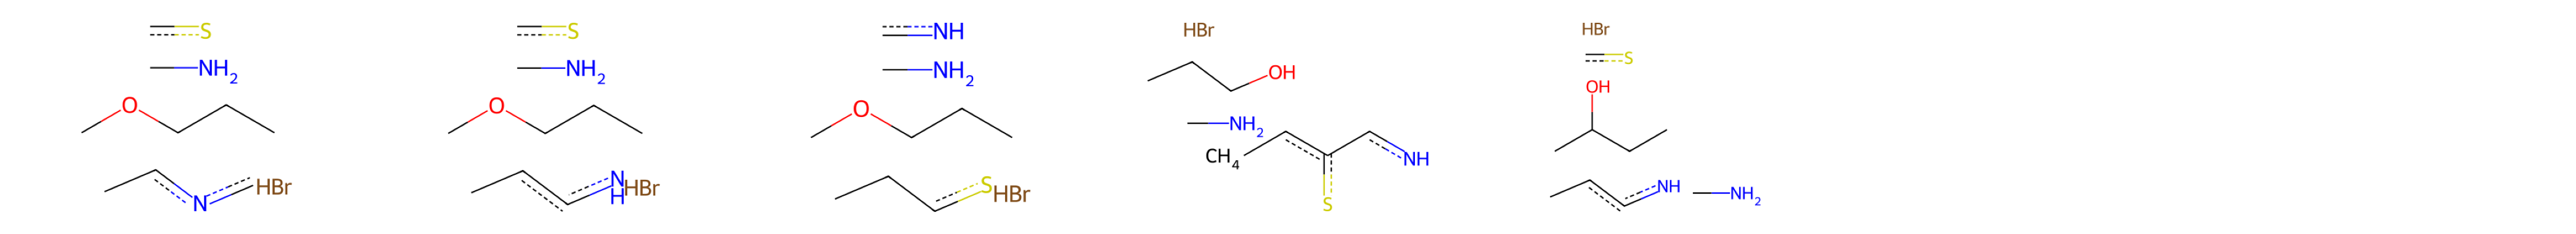

[graph 0] phase=3/5 depth=3 remaining_edges=5 step_time=0m 18.8s eta=1m 34.0s
generated=1230 feasible=166 retained=5 tried=3201
best_score=0.399 best_selection_score=0.204 best_repulsion=0.651
repulsion_lambda=0.300 beam_limit=5


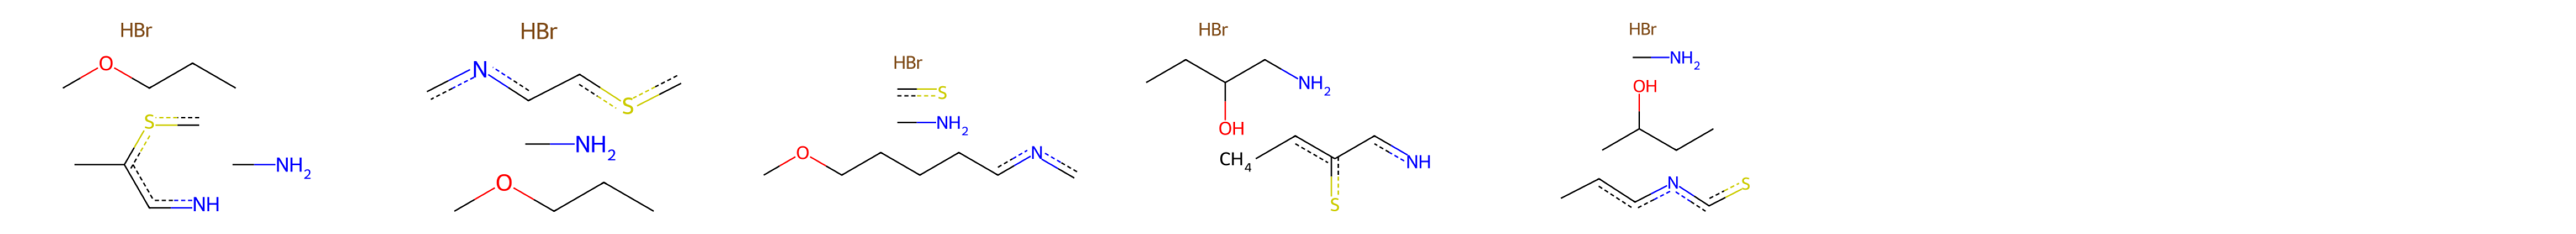

[graph 0] phase=3/5 depth=4 remaining_edges=4 step_time=0m 19.3s eta=1m 17.1s
generated=1215 feasible=109 retained=5 tried=4416
best_score=0.445 best_selection_score=0.253 best_repulsion=0.641
repulsion_lambda=0.300 beam_limit=5


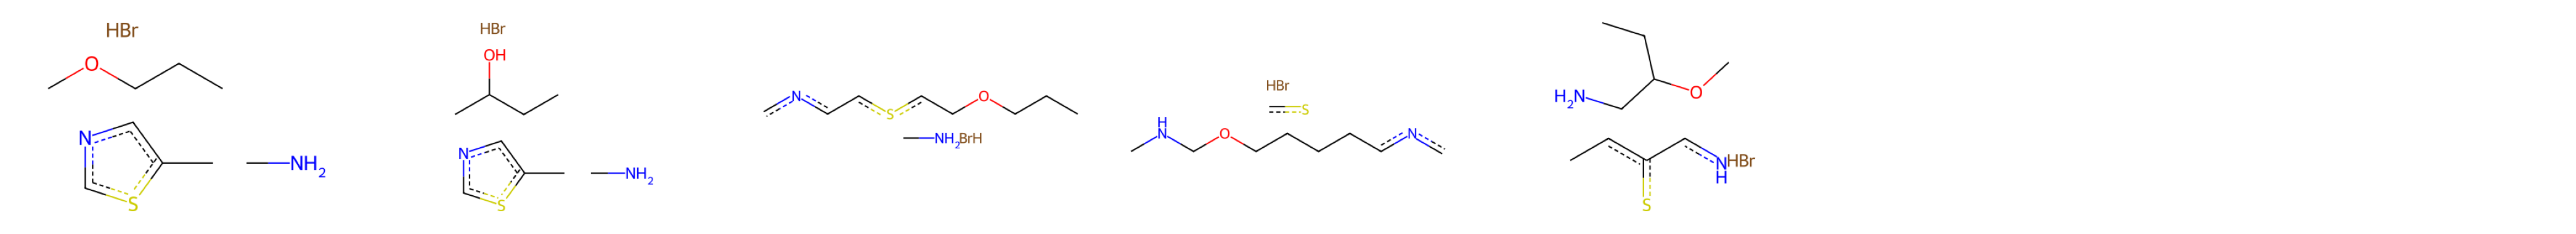

[graph 0] phase=3/5 depth=5 remaining_edges=3 step_time=0m 21.8s eta=1m 5.5s
generated=1200 feasible=66 retained=5 tried=5616
best_score=0.416 best_selection_score=0.216 best_repulsion=0.666
repulsion_lambda=0.300 beam_limit=5


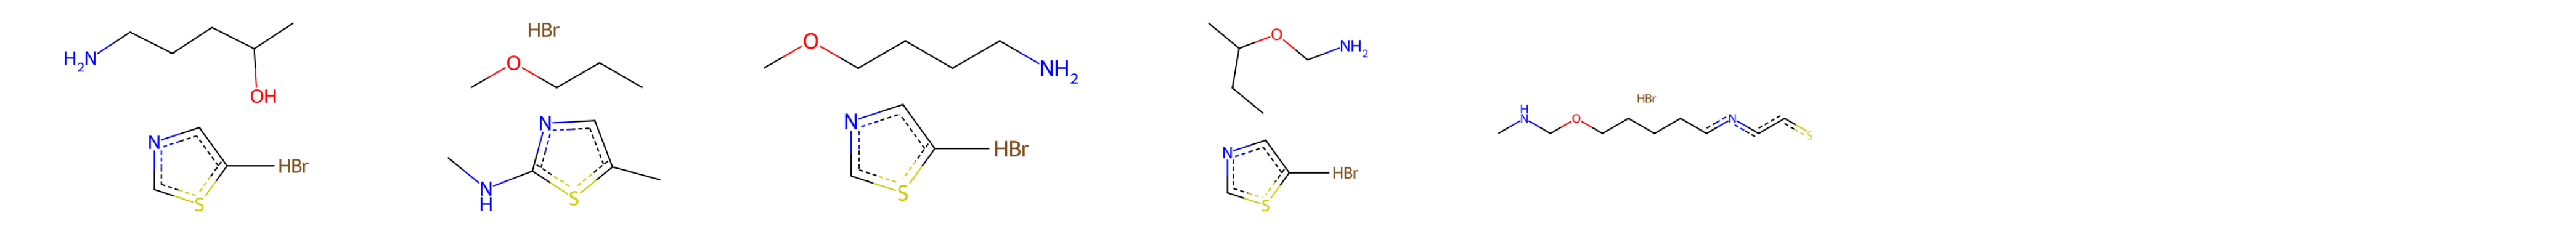

[graph 0] phase=3/5 depth=6 remaining_edges=2 step_time=0m 21.2s eta=0m 42.5s
generated=1185 feasible=44 retained=5 tried=6801
best_score=0.790 best_selection_score=0.579 best_repulsion=0.703
repulsion_lambda=0.300 beam_limit=5


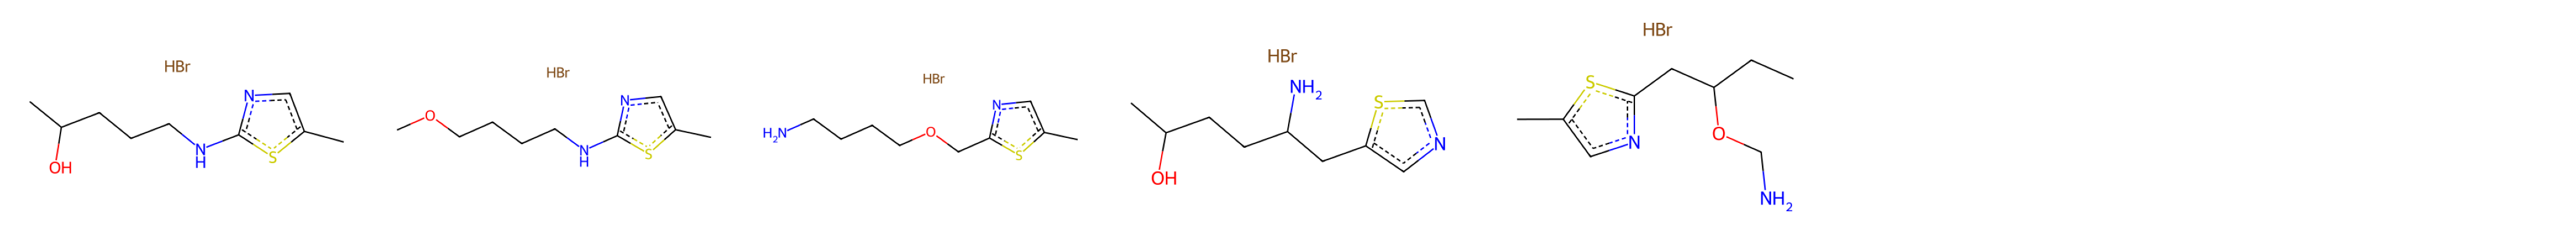

[graph 0] phase=3/5 depth=7 remaining_edges=0 step_time=0m 22.4s eta=0m 0.0s
generated=1170 feasible=0 retained=0 tried=7971
best_score=None
beam_limit=5
[graph 0] fallback=3/4 rollback_steps=8 surgical_repairs=4 to_depth=0 beam_limit=7
[graph 0] surgical_removed_edges=['(3, 4),(2, 12),(12, 13),(10, 12),(4, 13),(2, 8),(10, 11),(5, 8)', '(2, 13),(12, 13),(10, 12),(10, 11),(4, 11),(3, 8),(5, 8),(0, 9)', '(3, 4),(0, 4),(4, 11),(0, 1),(10, 12),(1, 6),(10, 11),(12, 13)', '(3, 4),(4, 11),(2, 8),(10, 11),(5, 8),(8, 9),(10, 12),(12, 13)']
[graph 0] phase=4/5 beam_limit=7 fallback=3/4
[graph 0] phase=4/5 depth=1 remaining_edges=9 step_time=0m 14.3s eta=2m 8.6s
generated=1032 feasible=371 retained=7 tried=9003
best_score=0.585 best_selection_score=0.333 best_repulsion=0.559
repulsion_lambda=0.450 beam_limit=7


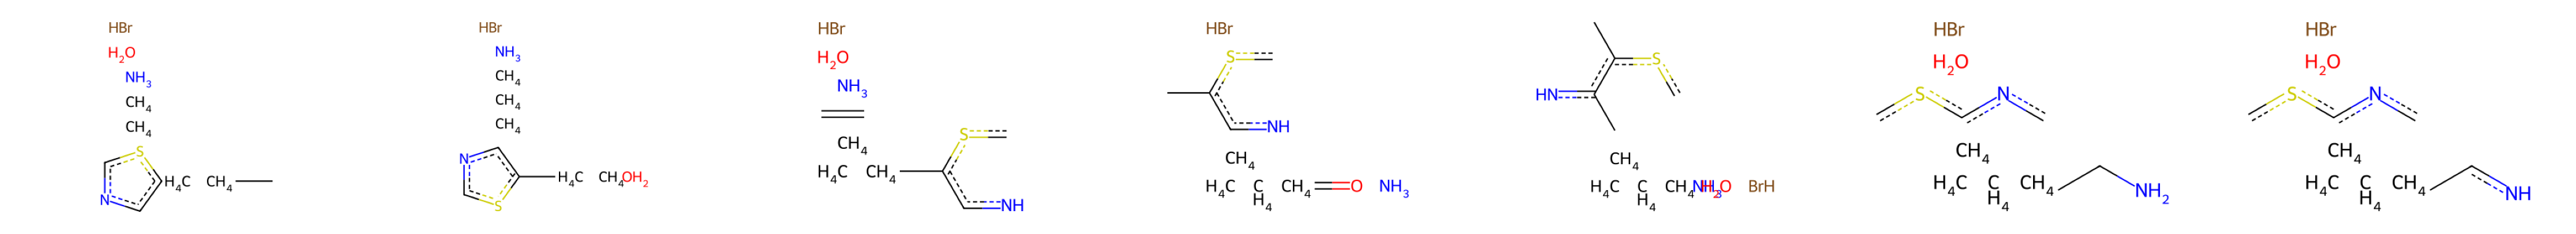

[graph 0] phase=4/5 depth=2 remaining_edges=8 step_time=0m 24.1s eta=3m 13.0s
generated=1785 feasible=517 retained=7 tried=10788
best_score=0.849 best_selection_score=0.582 best_repulsion=0.592
repulsion_lambda=0.450 beam_limit=7


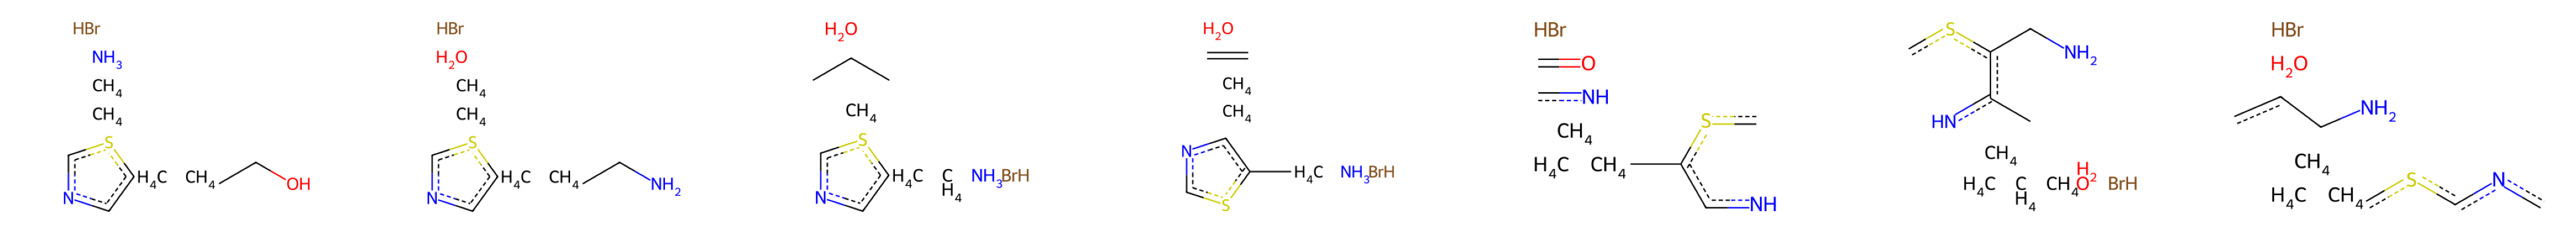

[graph 0] phase=4/5 depth=3 remaining_edges=7 step_time=0m 27.1s eta=3m 9.8s
generated=1764 feasible=416 retained=7 tried=12552
best_score=0.827 best_selection_score=0.538 best_repulsion=0.642
repulsion_lambda=0.450 beam_limit=7


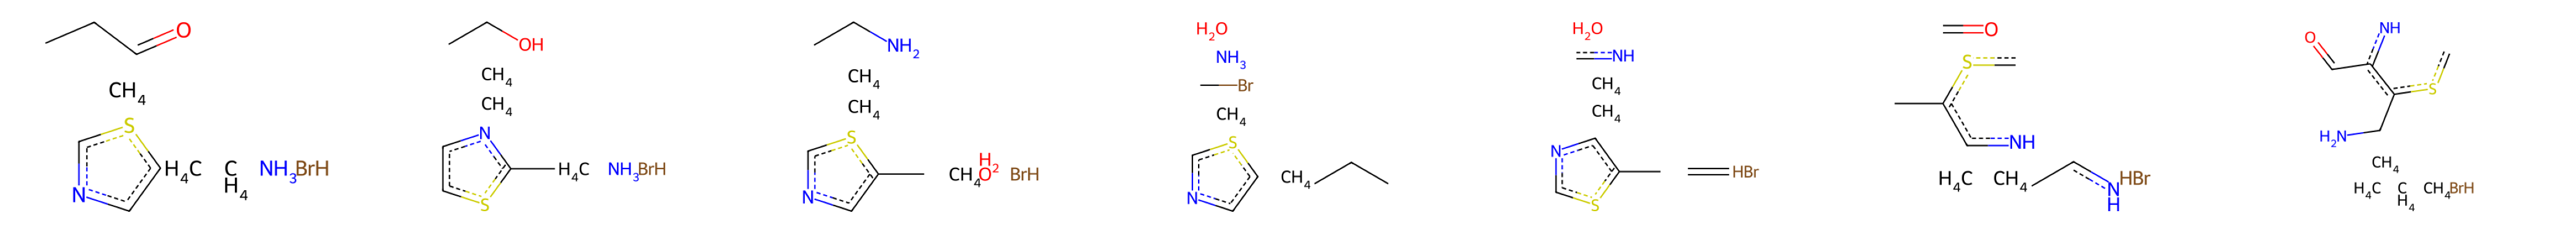

[graph 0] phase=4/5 depth=4 remaining_edges=6 step_time=0m 26.3s eta=2m 37.6s
generated=1743 feasible=311 retained=7 tried=14295
best_score=0.827 best_selection_score=0.507 best_repulsion=0.711
repulsion_lambda=0.450 beam_limit=7


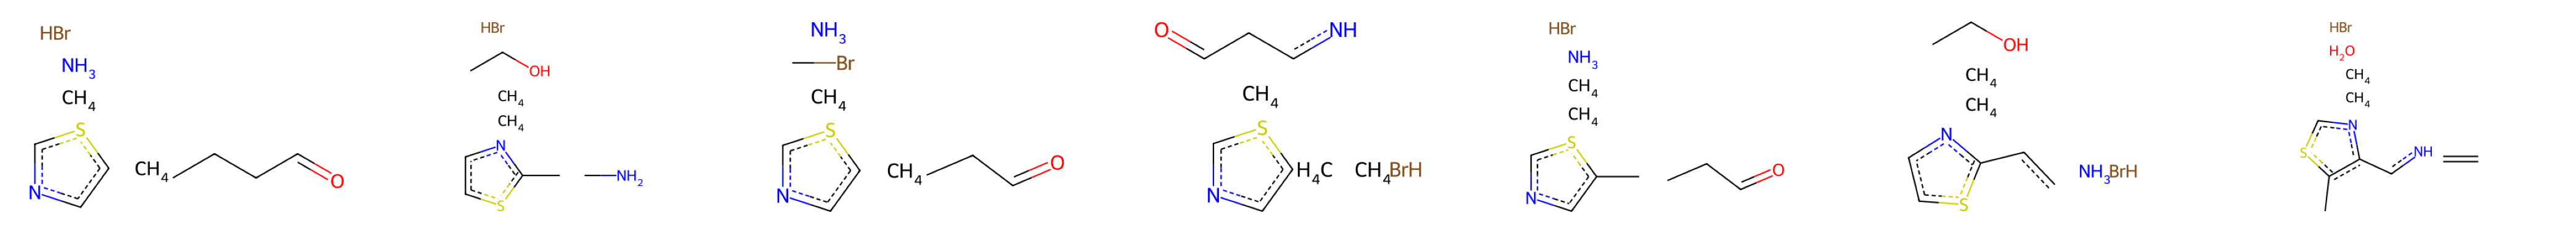

[graph 0] phase=4/5 depth=5 remaining_edges=5 step_time=0m 24.3s eta=2m 1.3s
generated=1722 feasible=219 retained=7 tried=16017
best_score=0.933 best_selection_score=0.608 best_repulsion=0.720
repulsion_lambda=0.450 beam_limit=7


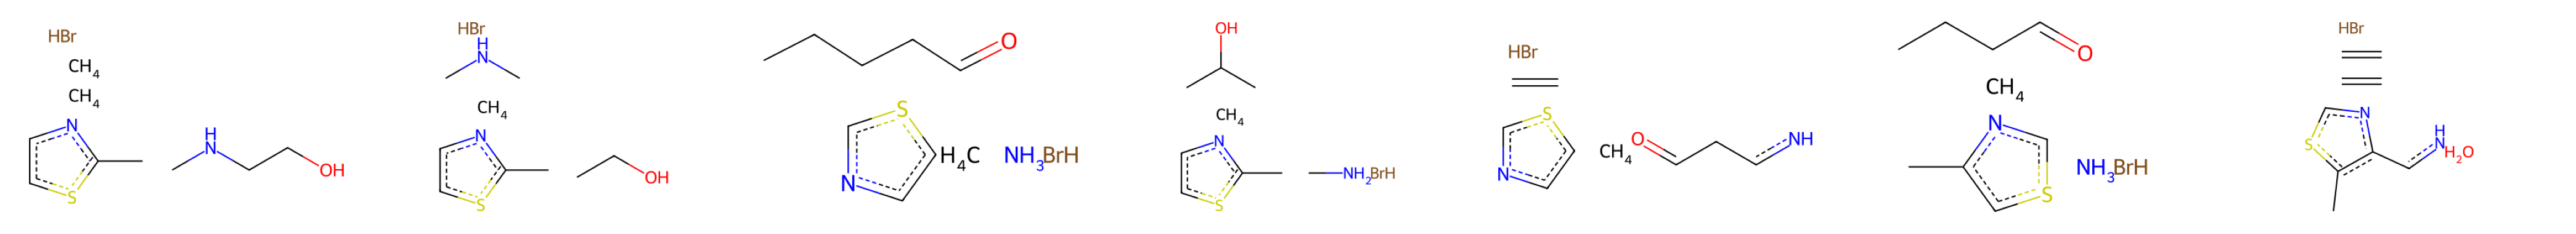

[graph 0] phase=4/5 depth=6 remaining_edges=4 step_time=0m 27.6s eta=1m 50.4s
generated=1701 feasible=149 retained=7 tried=17718
best_score=0.868 best_selection_score=0.544 best_repulsion=0.720
repulsion_lambda=0.450 beam_limit=7


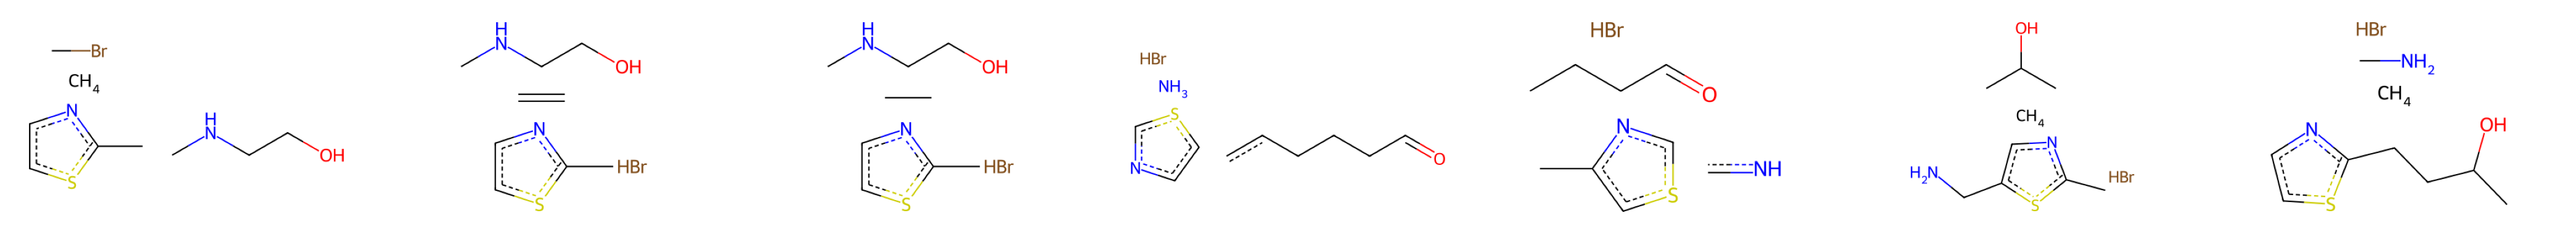

[graph 0] phase=4/5 depth=7 remaining_edges=3 step_time=0m 29.3s eta=1m 28.0s
generated=1680 feasible=124 retained=7 tried=19398
best_score=0.846 best_selection_score=0.524 best_repulsion=0.717
repulsion_lambda=0.450 beam_limit=7


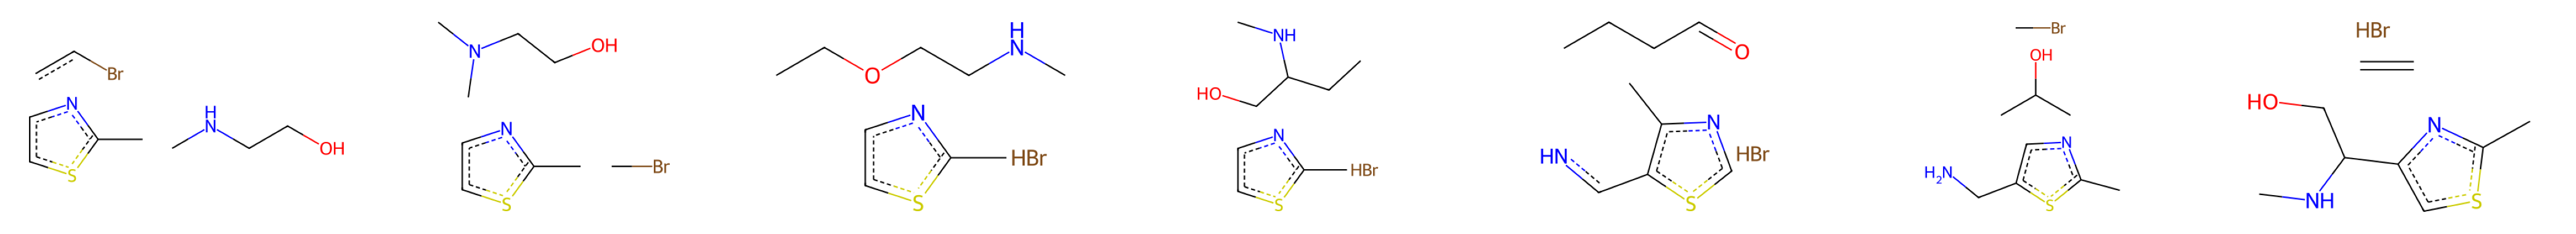

In [ ]:
%%time
repair_path = generator.repair(
    perturbed_graph,
    n_neighbors=7,
    target=repair_target,
    target_lambda=0.5,
    return_path=True,
    draw_graphs_fn=lambda graphs, **kwargs: display_graphs(graphs, n_graphs_per_line=7, **kwargs),
)

print(f"repair_path_length = {len(repair_path)}")
if len(repair_path) > 0:
    print(f"final_n_edges = {repair_path[-1].number_of_edges()}")
    display_graphs(repair_path, n_graphs_per_line=7)
    print('Original and perturbed graphs:')
    display_graphs([graph, perturbed_graph], n_graphs_per_line=2)
    print('Repaired graph:')
    display_graphs([repair_path[-1]], n_graphs_per_line=1)

---